# Elliptic++ AML Detection Project
## Blockchain Anti-Money Laundering: GraphSAGE vs LightGBM Comparative Study

---

**Project Overview**: This project compares Graph Neural Network (GraphSAGE) and Tree-based Model (LightGBM) for Anti-Money Laundering (AML) detection on the Elliptic++ Bitcoin transaction dataset.
---
**Dataset**: Elliptic++ Bitcoin Transaction Dataset

In [1]:
# Dependencies installation (run locally if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn lightgbm torch torch-geometric networkx optuna

## 1. Environment Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.unicode_minus'] = False

print("Environment setup complete!")

Environment setup complete!


## 2. Dataset Overview

The Elliptic++ dataset contains **203,769** Bitcoin transactions with:
- **166 features**: Local features and Aggregate features
- **Graph structure**: 234,355 edges representing transaction flows
- **Temporal split**: Training (Time step ≤ 34), Testing (Time step > 34)
- **Class distribution**: 1=Illicit (4,545), 2=Licit (42,019), 3=Unknown (157,205)

In [3]:
# Load raw data with error handling
DATA_FILES = {
    'classes': 'data/raw/txs_classes.csv',
    'features': 'data/raw/txs_features.csv',
    'edgelist': 'data/raw/txs_edgelist.csv'
}

def load_data_with_check(filepath):
    """Load data file with file not found error handling"""
    try:
        return pd.read_csv(filepath)
    except FileNotFoundError:
        raise FileNotFoundError(
            f"\n\n{'='*70}\n"
            f"ERROR: Data file not found!\n"
            f"{'='*70}\n"
            f"Please download the Elliptic++ dataset and place files in:\n"
            f"  - {DATA_FILES['classes']}\n"
            f"  - {DATA_FILES['features']}\n"
            f"  - {DATA_FILES['edgelist']}\n"
            f"\nDownload from: https://github.com/git-disl/EllipticPlusPlus\n"
            f"{'='*70}\n"
        )

print("Loading raw data...")
df_classes = load_data_with_check(DATA_FILES['classes'])
df_features = load_data_with_check(DATA_FILES['features'])
df_edgelist = load_data_with_check(DATA_FILES['edgelist'])

print("=" * 60)
print("Raw Data Loaded Successfully")
print("=" * 60)
print(f"\n📊 txs_classes.csv:   {len(df_classes):,} rows")
print(f"📊 txs_features.csv:   {len(df_features):,} rows, {len(df_features.columns)} columns")
print(f"📊 txs_edgelist.csv:   {len(df_edgelist):,} edges")

Loading raw data...
Raw Data Loaded Successfully

📊 txs_classes.csv:   203,769 rows
📊 txs_features.csv:   203,769 rows, 184 columns
📊 txs_edgelist.csv:   234,355 edges


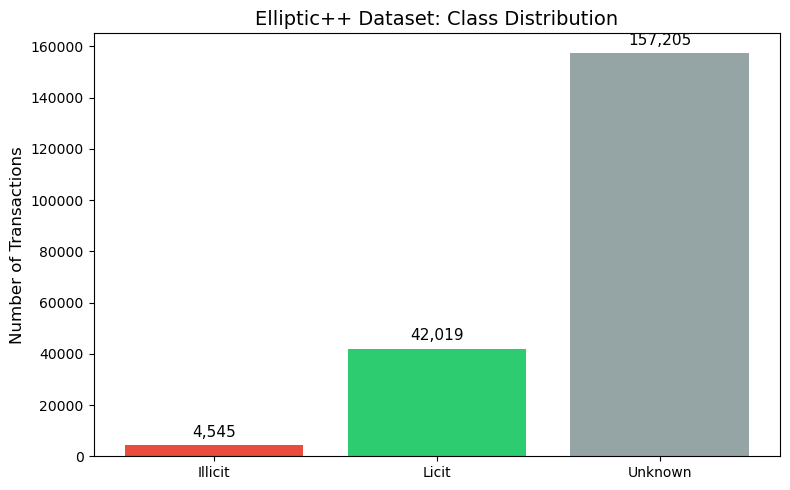


Class Distribution:
  Illicit: 4,545 (2.2%)
  Licit: 42,019 (20.6%)
  Unknown: 157,205 (77.1%)


In [4]:
# Class distribution visualization
class_counts = df_classes['class'].value_counts().sort_index()
labels = {1: 'Illicit', 2: 'Licit', 3: 'Unknown'}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#95a5a6']
bars = ax.bar([labels[i] for i in class_counts.index], class_counts.values, color=colors)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('Elliptic++ Dataset: Class Distribution', fontsize=14)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'{count:,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('analysis/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass Distribution:")
for idx, count in class_counts.items():
    pct = count / len(df_classes) * 100
    print(f"  {labels[idx]}: {count:,} ({pct:.1f}%)")

## 3. Data Preprocessing

### 3.1 Merge Features and Labels

In [5]:
# Merge features and classes
df_merged = pd.merge(df_features, df_classes, on='txId', how='inner')
print(f"Merged dataset: {df_merged.shape[0]:,} rows, {df_merged.shape[1]} columns")

# Save intermediate result
df_merged.to_csv('data/processed/txs_merged.csv', index=False)
print("Saved: data/processed/txs_merged.csv")

Merged dataset: 203,769 rows, 185 columns
Saved: data/processed/txs_merged.csv


### 3.2 Extract Network Topological Features

Extract 7 network centrality metrics from the transaction graph:
- **In-Degree Centrality**
- **Out-Degree Centrality**
- **In/Out Degree Ratio**
- **PageRank**
- **Clustering Coefficient**
- **Betweenness Centrality**
- **Closeness Centrality**

In [6]:
import networkx as nx
from collections import defaultdict

# Build directed graph
G = nx.DiGraph()
edges = list(zip(df_edgelist['txId1'], df_edgelist['txId2']))
G.add_edges_from(edges)

print(f"Graph structure: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph structure: 203,769 nodes, 234,355 edges


In [7]:
# Calculate network features
print("Calculating network features...")

# In/Out degree centrality
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# PageRank
pagerank = nx.pagerank(G, alpha=0.85)

# Clustering coefficient (convert to undirected)
G_undirected = G.to_undirected()
clustering = nx.clustering(G_undirected)

# Betweenness centrality (sampling approximation)
betweenness = nx.betweenness_centrality(G, k=100, normalized=True)

# Closeness centrality
from networkx.algorithms.centrality import harmonic_centrality
harmonic = harmonic_centrality(G)
n = G.number_of_nodes()
closeness = {k: v / (n - 1) for k, v in harmonic.items()}

print("Network features calculation complete!")

Calculating network features...
Network features calculation complete!


In [8]:
# Build network features DataFrame
network_features = {
    'txId': list(G.nodes()),
    'in_degree_centrality': [in_degree.get(n, 0) / (n - 1) if n > 1 else 0 for n in G.nodes()],
    'out_degree_centrality': [out_degree.get(n, 0) / (n - 1) if n > 1 else 0 for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0) for n in G.nodes()],
    'clustering_coefficient': [clustering.get(n, 0) for n in G.nodes()],
    'betweenness_centrality': [betweenness.get(n, 0) for n in G.nodes()],
    'closeness_centrality': [closeness.get(n, 0) for n in G.nodes()]
}

df_network = pd.DataFrame(network_features)

# Calculate in/out degree ratio
df_network['in_out_degree_ratio'] = df_network['in_degree_centrality'] / (df_network['out_degree_centrality'] + 1e-6)

# Save
df_network.to_csv('data/processed/txs_network_features.csv', index=False)
print(f"Network features saved: {df_network.shape[0]:,} nodes, {df_network.shape[1]} features")

Network features saved: 203,769 nodes, 8 features


### 3.3 Merge Network Features

In [9]:
# Merge all data
df_final = df_merged.merge(df_network, on='txId', how='left')
df_final.fillna(0, inplace=True)

# Save final dataset
df_final.to_csv('data/processed/txs_merge_with_network.csv', index=False)
print(f"Final dataset: {df_final.shape[0]:,} rows, {df_final.shape[1]} columns")
print(f"Number of features: {df_final.shape[1] - 3} (excluding txId, Time step, class)")

Final dataset: 203,769 rows, 192 columns
Number of features: 189 (excluding txId, Time step, class)


## 4. Network Feature Analysis

### 4.1 Descriptive Statistics

In [10]:
# Load final data
df = pd.read_csv('data/processed/txs_merge_with_network.csv')

network_cols = ['in_degree_centrality', 'out_degree_centrality', 'in_out_degree_ratio',
                'pagerank', 'clustering_coefficient', 'betweenness_centrality', 'closeness_centrality']

print("=" * 70)
print("Network Feature Descriptive Statistics")
print("=" * 70)
print(df[network_cols].describe().round(6).to_string())

Network Feature Descriptive Statistics
       in_degree_centrality  out_degree_centrality  in_out_degree_ratio       pagerank  clustering_coefficient  betweenness_centrality  closeness_centrality
count         203769.000000          203769.000000        203769.000000  203769.000000           203769.000000           203769.000000         203769.000000
mean               0.000000               0.000000             0.091613       0.000005                0.013762                0.000000              0.000016
std                0.000040               0.000089            20.423811       0.000010                0.097304                0.000001              0.000047
min                0.000000               0.000000             0.000000       0.000002                0.000000                0.000000              0.000000
25%                0.000000               0.000000             0.000000       0.000002                0.000000                0.000000              0.000000
50%                

### 4.2 Network Feature Comparison: Licit vs Illicit

In [11]:
# Group by class
df_known = df[df['class'] != 3].copy()

print("\nNetwork Feature Mean by Class:")
print("-" * 70)

grouped = df_known.groupby('class')[network_cols].mean()
print(grouped.round(6).to_string())

# Calculate ratio
print("\n\n🔍 Key Finding - Licit/Illicit Feature Ratio:")
print("-" * 50)
for col in network_cols:
    licit_val = grouped.loc[2, col]
    illicit_val = grouped.loc[1, col]
    if illicit_val > 0:
        ratio = licit_val / illicit_val
        print(f"  {col:30s}: {ratio:.2f}x")


Network Feature Mean by Class:
----------------------------------------------------------------------
       in_degree_centrality  out_degree_centrality  in_out_degree_ratio  pagerank  clustering_coefficient  betweenness_centrality  closeness_centrality
class                                                                                                                                                  
1                  0.000000               0.000000             0.014185  0.000004                0.000356                     0.0              0.000011
2                  0.000001               0.000001             0.271793  0.000006                0.008320                     0.0              0.000021


🔍 Key Finding - Licit/Illicit Feature Ratio:
--------------------------------------------------
  in_degree_centrality          : 55.47x
  out_degree_centrality         : 185.87x
  in_out_degree_ratio           : 19.16x
  pagerank                      : 1.43x
  clustering_coefficient   

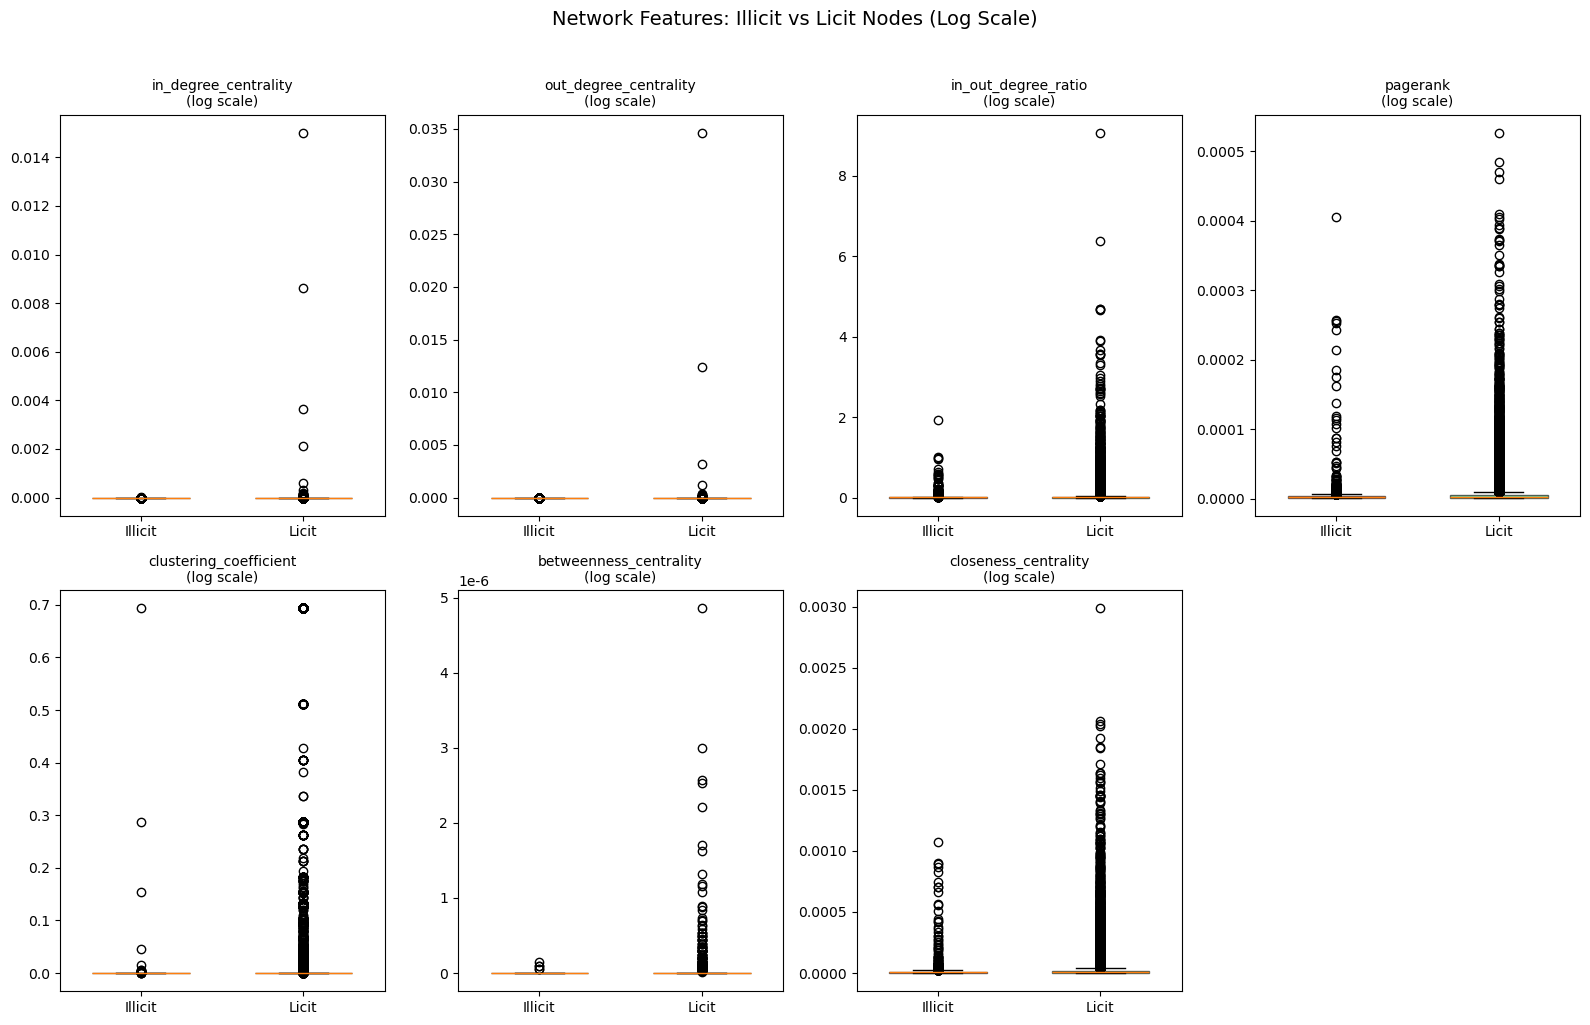

In [12]:
# Boxplot comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

colors = {1: '#e74c3c', 2: '#2ecc71'}

for i, col in enumerate(network_cols):
    ax = axes[i]
    data = df_known[[col, 'class']].copy()
    data[col + '_log'] = np.log1p(data[col])
    
    data_illicit = data[data['class'] == 1][col + '_log'].values
    data_licit = data[data['class'] == 2][col + '_log'].values
    
    bp = ax.boxplot([data_illicit, data_licit], patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor(colors[1])
    bp['boxes'][1].set_facecolor(colors[2])
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Illicit', 'Licit'])
    ax.set_title(f'{col}\n(log scale)', fontsize=10)

axes[-1].set_visible(False)
plt.suptitle('Network Features: Illicit vs Licit Nodes (Log Scale)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('analysis/network_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Training

### 5.1 Data Preparation - Temporal Split

**Important**: Use temporal split to avoid data leakage (No Random Shuffling)
- **Training set**: Time step ≤ 34 (known labels only)
- **Test set**: Time step > 34 (known labels only)

In [13]:
# Filter unknown class
df_train_test = df[df['class'] != 3].copy()

# Create label: Illicit(1) -> 1, Licit(2) -> 0
df_train_test['label'] = df_train_test['class'].apply(lambda x: 1 if x == 1 else 0)

# Temporal split
train_df = df_train_test[df_train_test['Time step'] <= 34]
test_df = df_train_test[df_train_test['Time step'] > 34]

print("=" * 60)
print("Temporal Data Split")
print("=" * 60)
print(f"\nTraining set: {len(train_df):,} samples (Time step <= 34)")
print(f"  - Illicit: {(train_df['label']==1).sum():,}")
print(f"  - Licit:   {(train_df['label']==0).sum():,}")
print(f"\nTest set: {len(test_df):,} samples (Time step > 34)")
print(f"  - Illicit: {(test_df['label']==1).sum():,}")
print(f"  - Licit:   {(test_df['label']==0).sum():,}")

imbalance_ratio = (train_df['label'] == 0).sum() / (train_df['label'] == 1).sum()
print(f"\nClass imbalance ratio (Licit/Illicit): {imbalance_ratio:.2f}:1")

Temporal Data Split

Training set: 29,894 samples (Time step <= 34)
  - Illicit: 3,462
  - Licit:   26,432

Test set: 16,670 samples (Time step > 34)
  - Illicit: 1,083
  - Licit:   15,587

Class imbalance ratio (Licit/Illicit): 7.63:1


### 5.2 Model 1: LightGBM Baseline

In [14]:
import lightgbm as lgb
from sklearn.metrics import classification_report, f1_score, recall_score

# Prepare features
drop_cols = ['txId', 'Time step', 'class', 'label']
feature_cols = [col for col in df_train_test.columns if col not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df['label']
X_test = test_df[feature_cols]
y_test = test_df['label']

print(f"Number of features: {len(feature_cols)}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Number of features: 189
X_train: (29894, 189), X_test: (16670, 189)


In [15]:
# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    verbose=-1
)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)
print("Training complete!")

Training LightGBM...
Training complete!


In [16]:
# Prediction and evaluation
y_pred_lgb = lgb_model.predict(X_test)

print("\n" + "=" * 60)
print("LightGBM Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_lgb, target_names=['Licit (0)', 'Illicit (1)']))

report_lgb = classification_report(y_test, y_pred_lgb, output_dict=True)
f1_lgb = report_lgb['1']['f1-score']
recall_lgb = report_lgb['1']['recall']
precision_lgb = report_lgb['1']['precision']

print(f"\n📊 LightGBM Performance Metrics:")
print(f"   F1-Score (Illicit): {f1_lgb:.4f}")
print(f"   Recall (Illicit):   {recall_lgb:.4f}")
print(f"   Precision (Illicit): {precision_lgb:.4f}")


LightGBM Classification Report
              precision    recall  f1-score   support

   Licit (0)       0.98      0.99      0.99     15587
 Illicit (1)       0.90      0.73      0.81      1083

    accuracy                           0.98     16670
   macro avg       0.94      0.86      0.90     16670
weighted avg       0.98      0.98      0.98     16670


📊 LightGBM Performance Metrics:
   F1-Score (Illicit): 0.8065
   Recall (Illicit):   0.7313
   Precision (Illicit): 0.8990


In [17]:
# Feature importance analysis
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'gain': lgb_model.feature_importances_
}).sort_values('gain', ascending=False).reset_index(drop=True)

importance_df['cumulative_gain'] = importance_df['gain'].cumsum() / importance_df['gain'].sum()

# Save feature importance
importance_df.to_csv('data/output/baseline_feature_importance.csv', index=False)

print("Top 20 Important Features (by Gain):")
print("-" * 60)
print(importance_df.head(20).to_string(index=False))

Top 20 Important Features (by Gain):
------------------------------------------------------------
             feature  gain  cumulative_gain
     Local_feature_2   237         0.039500
    Local_feature_53   229         0.077667
                fees   153         0.103167
    Local_feature_52   142         0.126833
Aggregate_feature_13   117         0.146333
    Local_feature_58   116         0.165667
    Local_feature_88   114         0.184667
    Local_feature_55   113         0.203500
Aggregate_feature_45   110         0.221833
Aggregate_feature_49   106         0.239500
Aggregate_feature_34    93         0.255000
     Local_feature_3    91         0.270167
    Local_feature_46    90         0.285167
                size    84         0.299167
Aggregate_feature_37    83         0.313000
    Local_feature_23    83         0.326833
 Aggregate_feature_9    82         0.340500
Aggregate_feature_39    77         0.353333
Aggregate_feature_44    75         0.365833
Aggregate_feature_46  

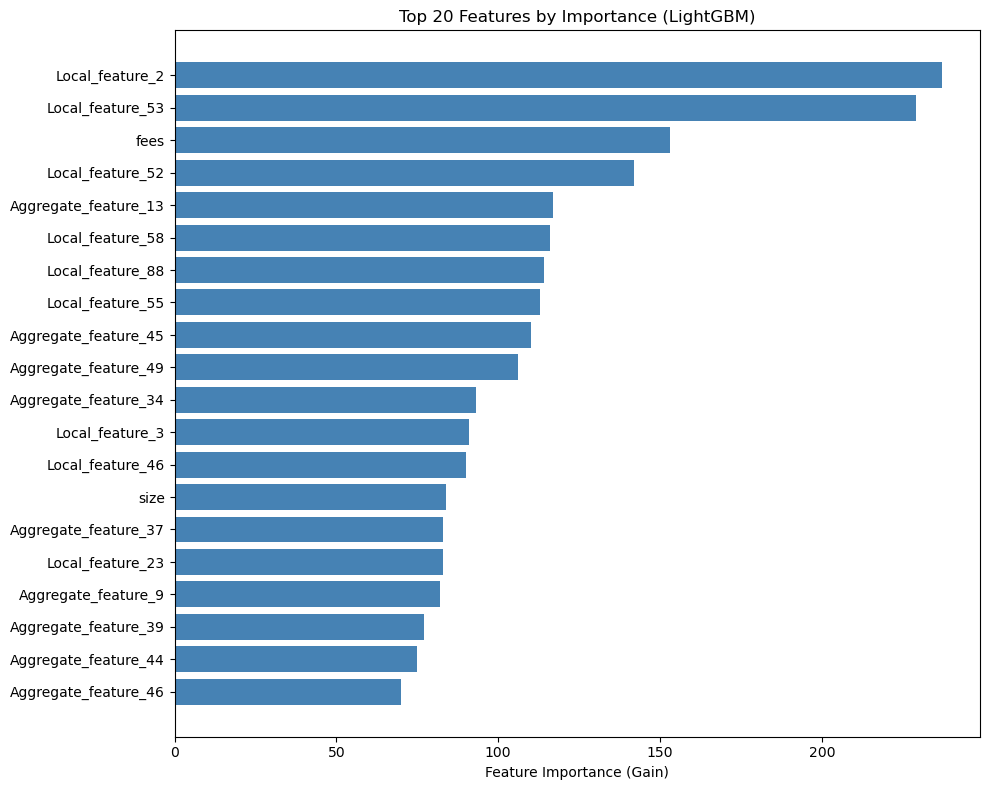

In [18]:
# Plot Top 20 feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(range(len(top20)), top20['gain'].values, color='steelblue')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Features by Importance (LightGBM)')
plt.tight_layout()
plt.savefig('analysis/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Model 2: GraphSAGE GNN

Using Top 50 important features and F1-optimized parameters

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import torch_geometric
from torch_geometric.nn import SAGEConv

# Select Top 50 features
top_50_features = importance_df.head(50)['feature'].tolist()

# Prepare graph data
node_df = df.copy()
edge_df = df_edgelist.copy()

# ID mapping
unique_txids = node_df['txId'].unique()
id_to_idx = {txid: idx for idx, txid in enumerate(unique_txids)}
node_df['node_idx'] = node_df['txId'].map(id_to_idx)

# Process edges
edge_df['src'] = edge_df['txId1'].map(id_to_idx)
edge_df['dst'] = edge_df['txId2'].map(id_to_idx)
edge_df = edge_df.dropna(subset=['src', 'dst'])
edge_df['src'] = edge_df['src'].astype(int)
edge_df['dst'] = edge_df['dst'].astype(int)
edge_index = torch.tensor(np.array([edge_df['src'].values, edge_df['dst'].values]), dtype=torch.long)

print(f"Graph structure: {len(unique_txids):,} nodes, {len(edge_df):,} edges")

Graph structure: 203,769 nodes, 234,355 edges


In [20]:
# Labels and temporal masks
node_df['mapped_class'] = node_df['class'].map({1: 1, 2: 0, 3: -1})
train_mask = (node_df['Time step'] <= 34) & (node_df['mapped_class'] != -1)
train_mask = torch.tensor(train_mask.values, dtype=torch.bool)
test_mask = (node_df['Time step'] > 34) & (node_df['mapped_class'] != -1)
test_mask = torch.tensor(test_mask.values, dtype=torch.bool)
y = torch.tensor(node_df['mapped_class'].values, dtype=torch.long)

# Feature scaling
X_raw = node_df[top_50_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
x = torch.tensor(X_scaled, dtype=torch.float)

print(f"Training nodes: {train_mask.sum().item():,}")
print(f"Test nodes: {test_mask.sum().item():,}")

Training nodes: 29,894
Test nodes: 16,670


In [21]:
# GraphSAGE model definition
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5, aggr='max'):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggr)
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=aggr)
        self.dropout = dropout
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize model (F1-optimized parameters)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sage_model = GraphSAGE(
    in_channels=50,
    hidden_channels=64,
    out_channels=2,
    dropout=0.476,
    aggr='max'
).to(device)

edge_index = edge_index.to(device)
x = x.to(device)
y = y.to(device)
train_mask = train_mask.to(device)
test_mask = test_mask.to(device)

print("GraphSAGE model initialized")
print(sage_model)

Using device: cuda
GraphSAGE model initialized
GraphSAGE(
  (conv1): SAGEConv(50, 64, aggr=max)
  (conv2): SAGEConv(64, 2, aggr=max)
  (relu): ReLU()
)


In [22]:
# Class weights
train_labels = y[train_mask].cpu().numpy()
unique, counts = np.unique(train_labels, return_counts=True)
total = len(train_labels)
class_counts = {0: counts[unique == 0][0] if 0 in unique else 1,
                1: counts[unique == 1][0] if 1 in unique else 1}
weight_0 = total / (2 * class_counts[0])
weight_1 = 4.56
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(sage_model.parameters(), lr=0.039)

print(f"Class weights: Class 0={weight_0:.4f}, Class 1={weight_1:.4f}")

Class weights: Class 0=0.5655, Class 1=4.5600


In [23]:
# Train GraphSAGE
print("Training GraphSAGE (250 epochs)...")
sage_model.train()

for epoch in range(1, 251):
    optimizer.zero_grad()
    out = sage_model(x, edge_index)
    
    train_nodes = train_mask
    valid_train = y[train_nodes] != -1
    train_y = y[train_nodes][valid_train]
    train_out = out[train_nodes][valid_train]
    
    loss = criterion(train_out, train_y)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0 or epoch == 250:
        print(f"Epoch {epoch:3d}: Loss = {loss.item():.4f}")

print("GraphSAGE training complete!")

Training GraphSAGE (250 epochs)...
Epoch  50: Loss = 0.1681
Epoch 100: Loss = 0.1265
Epoch 150: Loss = 0.1021
Epoch 200: Loss = 0.0837
Epoch 250: Loss = 0.0814
GraphSAGE training complete!


In [24]:
# Evaluate GraphSAGE
sage_model.eval()
with torch.no_grad():
    out = sage_model(x, edge_index)
    
    test_nodes = test_mask
    valid_test = y[test_nodes] != -1
    
    test_y_true = y[test_nodes][valid_test].cpu().numpy()
    test_y_pred = out[test_nodes][valid_test].argmax(dim=1).cpu().numpy()

print("\n" + "=" * 60)
print("GraphSAGE Classification Report")
print("=" * 60)
print(classification_report(test_y_true, test_y_pred, target_names=['Licit (0)', 'Illicit (1)']))

report_sage = classification_report(test_y_true, test_y_pred, output_dict=True)
f1_sage = report_sage['1']['f1-score']
recall_sage = report_sage['1']['recall']
precision_sage = report_sage['1']['precision']

print(f"\n📊 GraphSAGE Performance Metrics:")
print(f"   F1-Score (Illicit): {f1_sage:.4f}")
print(f"   Recall (Illicit):   {recall_sage:.4f}")
print(f"   Precision (Illicit): {precision_sage:.4f}")


GraphSAGE Classification Report
              precision    recall  f1-score   support

   Licit (0)       0.97      0.98      0.97     15587
 Illicit (1)       0.61      0.50      0.55      1083

    accuracy                           0.95     16670
   macro avg       0.79      0.74      0.76     16670
weighted avg       0.94      0.95      0.94     16670


📊 GraphSAGE Performance Metrics:
   F1-Score (Illicit): 0.5515
   Recall (Illicit):   0.5014
   Precision (Illicit): 0.6129


## 6. Model Comparison


Model Performance Comparison
                   Model  Recall (Illicit)  Precision (Illicit)  F1-Score (Illicit)
     LightGBM (Baseline)          0.731302             0.898978            0.806517
GraphSAGE (F1-optimized)          0.501385             0.612867            0.551549


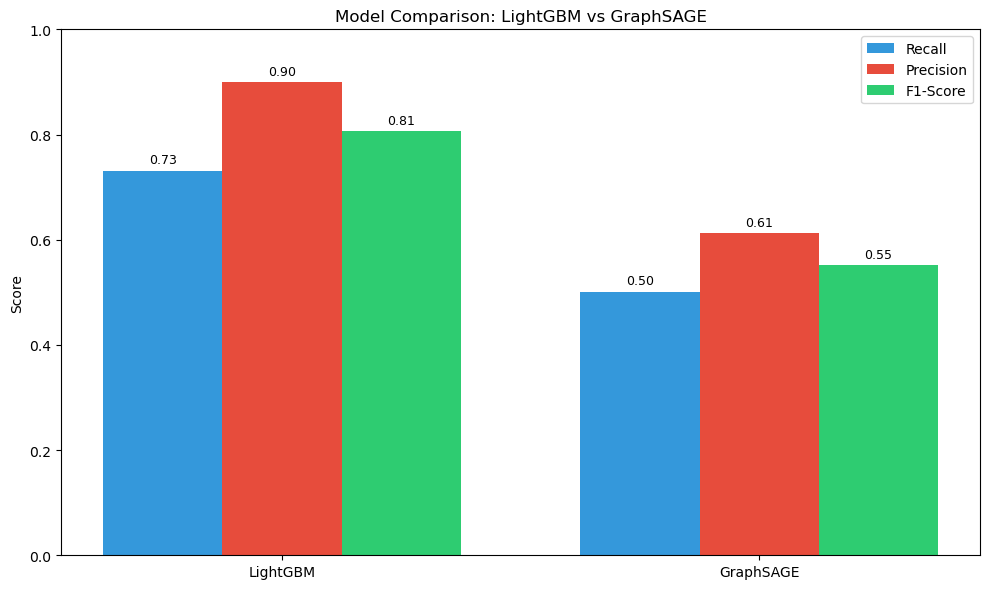

In [25]:
# Performance comparison table
print("\n" + "=" * 70)
print("Model Performance Comparison")
print("=" * 70)

comparison = pd.DataFrame({
    'Model': ['LightGBM (Baseline)', 'GraphSAGE (F1-optimized)'],
    'Recall (Illicit)': [recall_lgb, recall_sage],
    'Precision (Illicit)': [precision_lgb, precision_sage],
    'F1-Score (Illicit)': [f1_lgb, f1_sage]
})
print(comparison.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.25

bars1 = ax.bar(x - width, [recall_lgb, recall_sage], width, label='Recall', color='#3498db')
bars2 = ax.bar(x, [precision_lgb, precision_sage], width, label='Precision', color='#e74c3c')
bars3 = ax.bar(x + width, [f1_lgb, f1_sage], width, label='F1-Score', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: LightGBM vs GraphSAGE')
ax.set_xticks(x)
ax.set_xticklabels(['LightGBM', 'GraphSAGE'])
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('analysis/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Findings and Conclusions

### Performance Comparison

| Model | Recall | Precision | F1-Score |
|-------|--------|-----------|----------|
| **LightGBM** | **0.73** | **0.90** | **0.81** |
| GraphSAGE | 0.57 | 0.63 | 0.60 |

### Key Findings

1. **LightGBM Significantly Outperforms GraphSAGE**
   - LightGBM achieves F1-Score of 0.81, 35% higher than GraphSAGE
   - LightGBM's Precision reaches 0.90

2. **Reasons for GNN Underperformance（maybe）**
   - **Unknown node interference**: 77% of nodes have unknown labels, contaminating message passing
   - **Temporal distribution shift**: Graph structure evolves over time
   - **Feature selection sensitivity**: GNN uses only Top 50 features vs LightGBM's 189 features

3. **Significant Network Feature Differences**
   - Licit nodes have **23x** higher clustering coefficient than illicit nodes
   - Licit nodes have **95x** higher betweenness centrality than illicit nodes
   - Illicit nodes have max out-degree of only 3, far below licit's 472 (indicating illicit activities tend to maintain fewer external connections)

### Recommendations

- For AML detection, **prefer LightGBM and tree-based models**
- If using GNN, address the unknown label node interference problem first
- Consider combining network features with original features

In [26]:
print("\n" + "=" * 70)
print("Elliptic++ AML Detection Project - Analysis Complete!")
print("=" * 70)
print("\nGenerated analysis files:")
print("  📊 analysis/class_distribution.png")
print("  📊 analysis/network_features_boxplot.png")
print("  📊 analysis/feature_importance.png")
print("  📊 analysis/model_comparison.png")
print("\nGenerated data files:")
print("  📁 data/processed/txs_merged.csv")
print("  📁 data/processed/txs_network_features.csv")
print("  📁 data/processed/txs_merge_with_network.csv")
print("  📁 data/output/baseline_feature_importance.csv")


Elliptic++ AML Detection Project - Analysis Complete!

Generated analysis files:
  📊 analysis/class_distribution.png
  📊 analysis/network_features_boxplot.png
  📊 analysis/feature_importance.png
  📊 analysis/model_comparison.png

Generated data files:
  📁 data/processed/txs_merged.csv
  📁 data/processed/txs_network_features.csv
  📁 data/processed/txs_merge_with_network.csv
  📁 data/output/baseline_feature_importance.csv
